# 03 – VADER Sentiment-Analyse

Berechnung von Sentiment Scores für `Review Text` aus `data/processed/reviews_cleaned.csv` mittels VADER (Valence Aware Dictionary and sEntiment Reasoner). VADER ist lexikonbasiert und berücksichtigt unter anderem Grossschreibung und Satzzeichen (z. B. "!") zur Bestimmung der Intensität. Daher wurde der Text in `02_Data_Cleaning.ipynb` bewusst nicht in Kleinbuchstaben umgewandelt oder von Satzzeichen befreit.

Ergebnis: `data/processed/reviews_vader.csv`, Basis für `04_Regression.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

df = pd.read_csv(PROCESSED_DIR / "reviews_cleaned.csv")
df.shape

(22640, 13)

Die 22'640 Zeilen stimmen mit dem Endergebnis aus `02_Data_Cleaning.ipynb` überein. Die 13 Spalten setzen sich aus den ursprünglichen 11 Spalten sowie den beiden neu erstellten Merkmalen `Review Word Count` und `Review Char Count` zusammen.

## Sentiment-Scores berechnen

Für jede Rezension berechnet VADER vier Werte: die Anteile negativer, neutraler und positiver Textbestandteile (`VADER Negative`, `VADER Neutral`, `VADER Positive`) sowie den zusammenfassenden `VADER Compound` Score, der die Gesamtstimmung auf einer Skala von -1 (sehr negativ) bis +1 (sehr positiv) abbildet.


In [3]:
analyzer = SentimentIntensityAnalyzer()

scores = df["Review Text"].apply(analyzer.polarity_scores)
scores_df = pd.DataFrame(scores.tolist(), index=df.index)
scores_df = scores_df.rename(columns={
    "neg": "VADER Negative",
    "neu": "VADER Neutral",
    "pos": "VADER Positive",
    "compound": "VADER Compound",
})

df = pd.concat([df, scores_df], axis=1)
df[["Review Text", "VADER Negative", "VADER Neutral", "VADER Positive", "VADER Compound"]].head()

,Review Text,VADER Negative,VADER Neutral,VADER Positive,VADER Compound
0,Absolutely wonderful - silky and sexy and comf...,0.000,0.319,0.681,0.8932
1,Love this dress! it's sooo pretty. i happened ...,0.000,0.702,0.298,0.9729
2,I had such high hopes for this dress and reall...,0.025,0.831,0.144,0.9208
3,"I love, love, love this jumpsuit. it's fun, fl...",0.207,0.396,0.397,0.5727
4,This shirt is very flattering to all due to th...,0.000,0.700,0.300,0.9291


## Sentiment-Klasse

Klassifikation anhand der von VADER empfohlenen Schwellenwerte für den Compound-Score:
- `compound >= 0.05` → positiv
- `compound <= -0.05` → negativ
- `(−0,05 < compound < 0,05)` → neutral

In [ ]:
def classify_sentiment(compound: float) -> str:
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"

df["VADER Sentiment"] = df["VADER Compound"].map(classify_sentiment)
df["VADER Sentiment"].value_counts()

VADER Sentiment
positive    21041
negative     1335
neutral       264
Name: count, dtype: int64

Mit rund 93 Prozent zeigt sich eine deutliche Mehrheit positiver Bewertungen. Dies deckt sich mit der Beobachtung aus `01_Data_Import.ipynb`, wonach die durchschnittliche Sternebewertung bereits bei 4,2 von 5 lag. Diese Unausgewogenheit (Imbalance) der Kategorien kann bei der späteren Interpretation der Regressionsergebnisse relevant sein.


## Verteilung des Compound-Scores

In [5]:
df["VADER Compound"].describe()

count    22640.000000
mean         0.740525
std          0.366749
min         -0.953200
25%          0.717700
50%          0.891000
75%          0.950100
max          0.995600
Name: VADER Compound, dtype: float64

Diese Werte bestätigen die zuvor beobachtete positive Tendenz. Der Median liegt bei 0,891, das heisst, mindestens die Hälfte aller Reviews weist einen Compound Wert von 0,891 oder höher auf. Bereits das 25 Prozent Quantil liegt bei 0,72, sodass 75 Prozent aller Reviews einen Compound Wert von mindestens 0,72 aufweisen. Dies unterstreicht die deutliche Verschiebung der Daten in Richtung positiver Bewertungen.


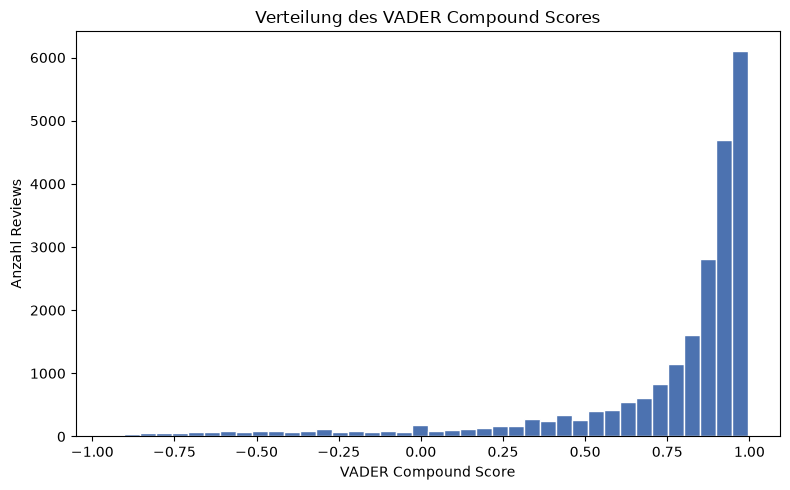

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["VADER Compound"], bins=40, color="#4C72B0", edgecolor="white")
ax.set_xlabel("VADER Compound Score")
ax.set_ylabel("Anzahl Reviews")
ax.set_title("Verteilung des VADER Compound Scores")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "vader_compound_distribution.png", dpi=150)
plt.show()

Die y-Achse zeigt die Anzahl der Reviews je Wertebereich (Bin) und nicht die Gesamtzahl aller Reviews. Da sich die Werte stark im Bereich nahe +1 konzentrieren, entfällt ein grosser Anteil der insgesamt 22'640 Reviews auf die letzten Bins. Dies erklärt die hohen Balken am rechten Rand der Verteilung.

Die Wahl von 40 Bins bietet bei 22'640 Beobachtungen eine gute Balance zwischen Detailgenauigkeit und Lesbarkeit des Histogramms.

## Plausibilitätscheck: VADER-Sentiment vs. Sternebewertung (Rating)

In [7]:
pd.crosstab(df["Rating"], df["VADER Sentiment"])

VADER Sentiment,negative,neutral,positive
Rating,,,
1,284,27,510
2,337,54,1158
3,371,83,2369
4,197,58,4653
5,146,42,12351


Die Kreuztabelle zeigt eine grundsätzlich plausible Übereinstimmung: Reviews mit 5 Sternen werden überwiegend als `positive` eingestuft, während Reviews mit 1 Stern den höchsten Anteil an `negative` Klassifikationen aufweisen. Dennoch werden auch bei niedrigen Ratings teilweise positive Sentiment Werte vergeben. Dies liegt daran, dass VADER ausschliesslich den Review Text bewertet. Faktoren wie Passform oder Lieferung, die das Rating ebenfalls beeinflussen können, werden dabei nicht berücksichtigt.


In [8]:
mean_compound_by_rating = df.groupby("Rating")["VADER Compound"].mean()
mean_compound_by_rating

Rating
1    0.213073
2    0.398747
3    0.542984
4    0.750656
5    0.857790
Name: VADER Compound, dtype: float64

Der mittlere VADER Compound Score steigt konsistent mit dem Rating an, von 0,21 bei 1 Stern auf 0,86 bei 5 Sternen. Dieser klare, monotone Zusammenhang bestätigt die Plausibilität der Sentiment Analysis auf aggregierter Ebene.

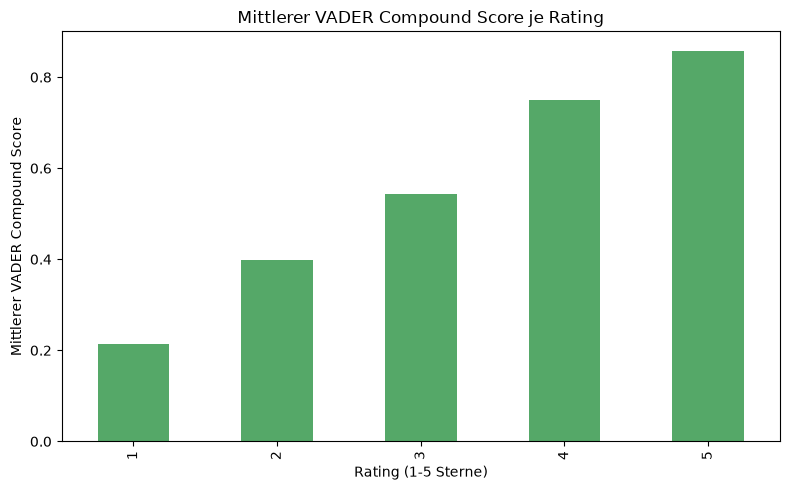

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
mean_compound_by_rating.plot(kind="bar", ax=ax, color="#55A868")
ax.set_xlabel("Rating (1-5 Sterne)")
ax.set_ylabel("Mittlerer VADER Compound Score")
ax.set_title("Mittlerer VADER Compound Score je Rating")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "vader_compound_by_rating.png", dpi=150)
plt.show()

## Speichern

Der Datensatz inklusive der berechneten VADER Sentiment Scores wird unter `data/processed/reviews_vader.csv` gespeichert und bildet die Grundlage für die Regressionsanalysen in `04_Regression.ipynb`.

In [10]:
out_path = PROCESSED_DIR / "reviews_vader.csv"
df.to_csv(out_path, index=False)
out_path

PosixPath('/Users/laraeibel/Desktop/Bachelorarbeit_Python/data/processed/reviews_vader.csv')